# Validações Estatísticas do BeamNG como Digital Twin

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

### 1 Explorando os datasets Circuito 4

#### 1.1 Simulado

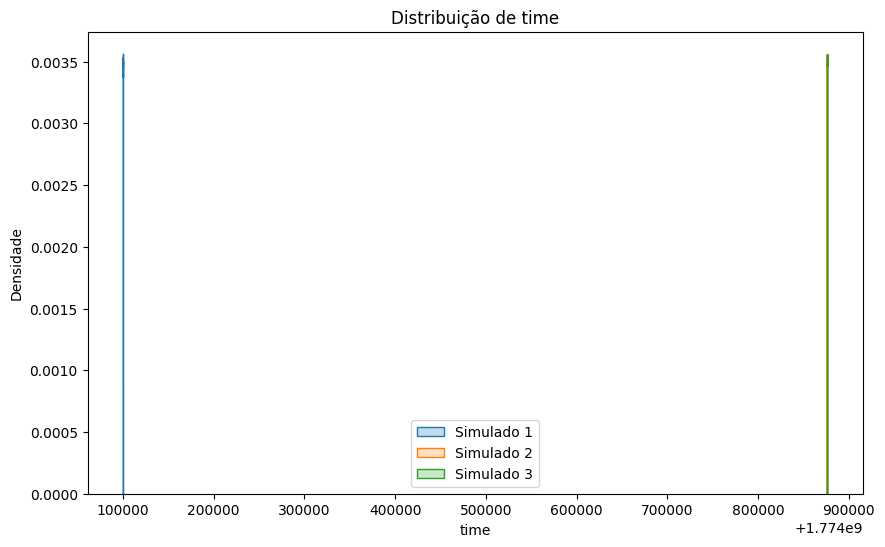

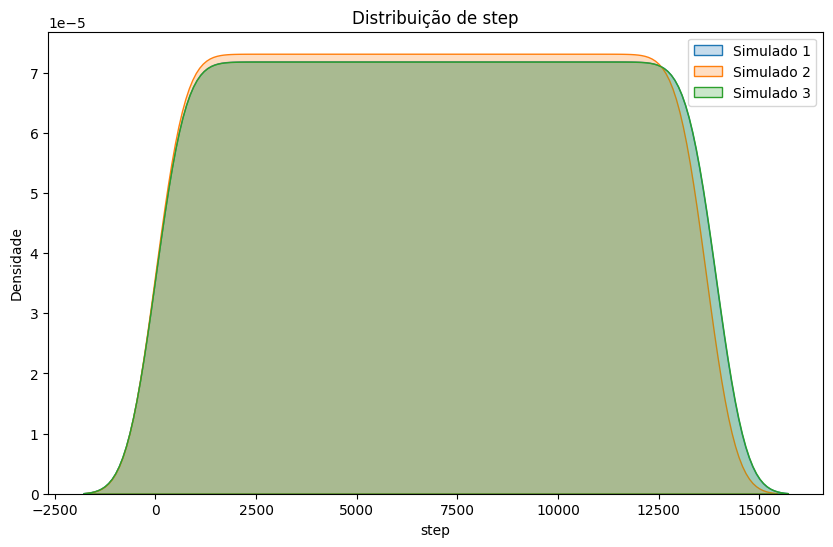

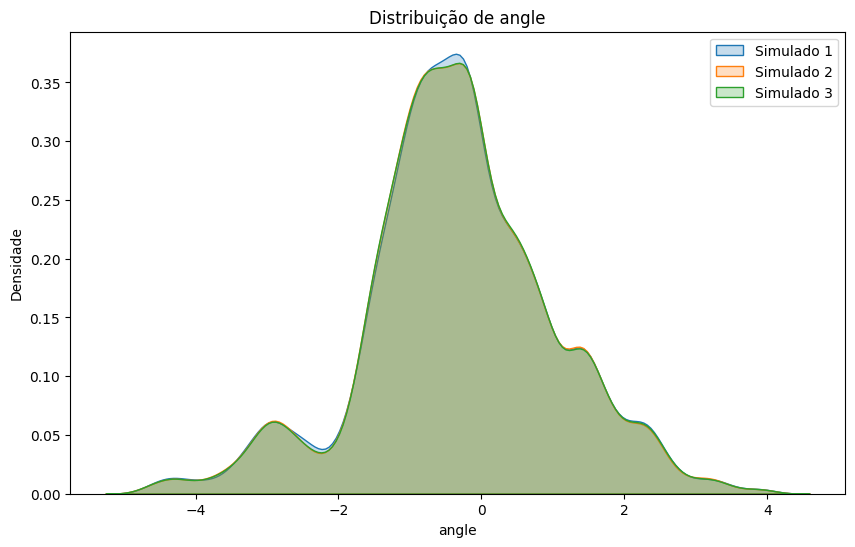

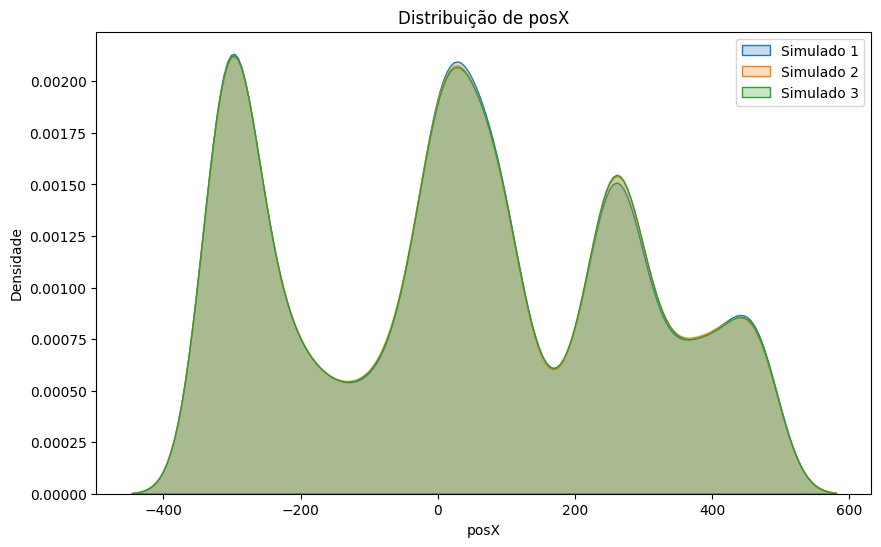

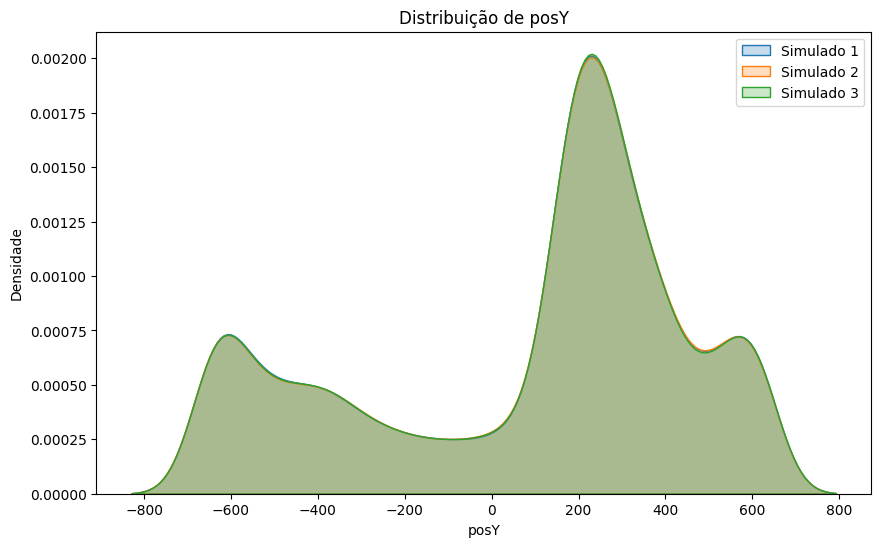

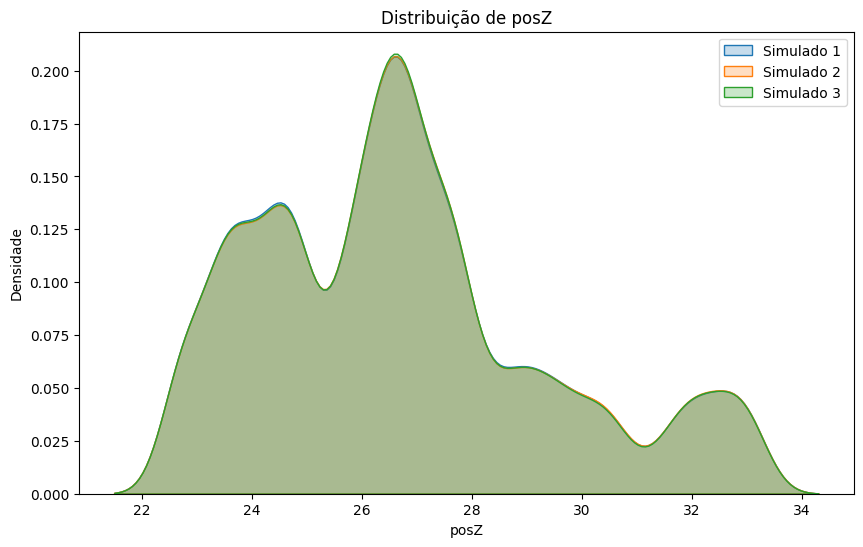

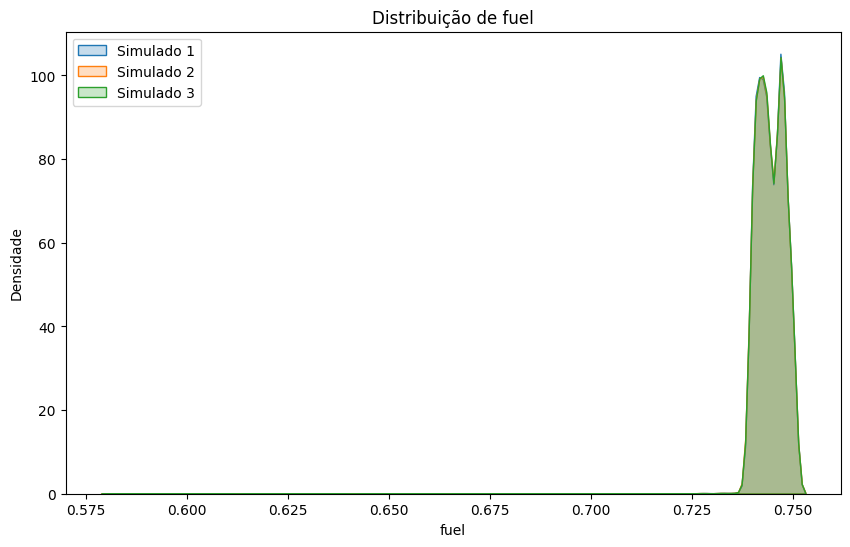

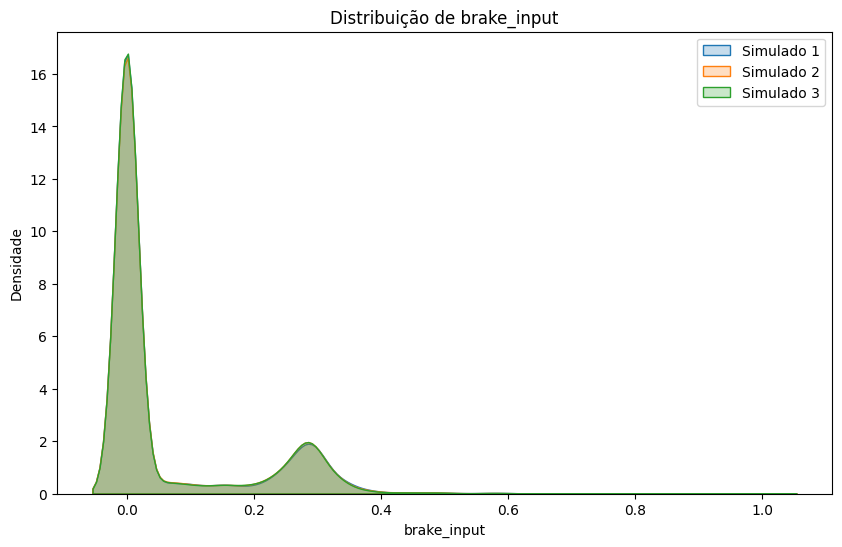

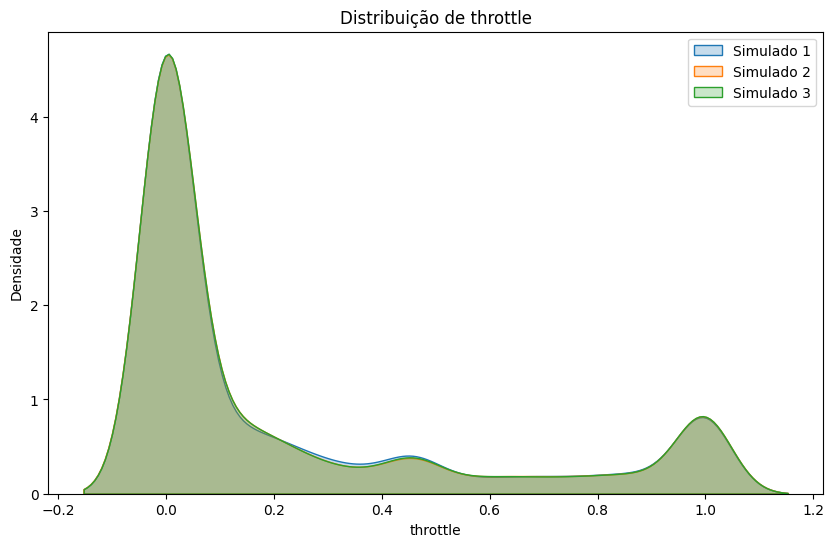

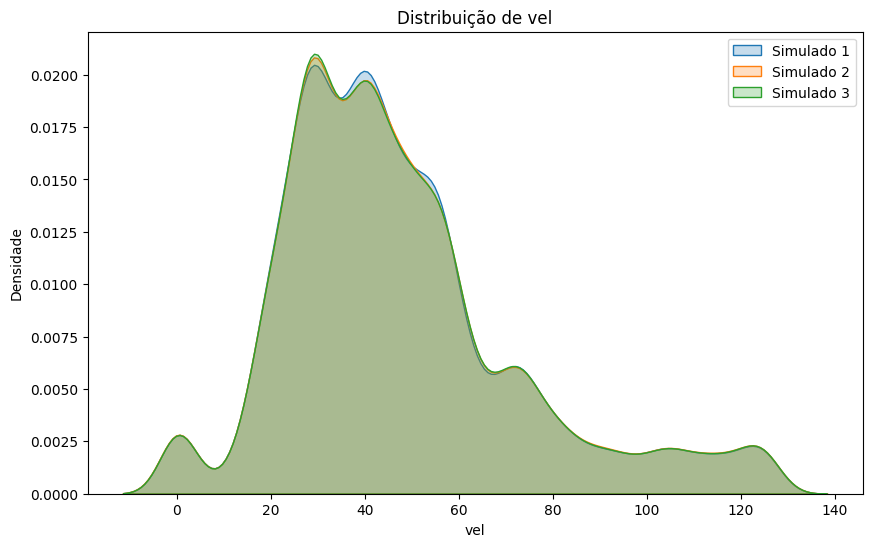

In [92]:
from os import listdir
import ast

simulados = []

for dir in listdir('../data/Circuito 4/'):
    simulados.append(pd.read_csv(f'../data/Circuito 4/{dir}/readable.csv', sep=';'))

colluns = simulados[0].columns

# Convertendo a coluna de velocidade para km/h
for simulado in simulados:
    simulado['vel'] = simulado['vel'].apply(
    lambda x: np.sqrt(sum(i**2 for i in ast.literal_eval(x))) * 3.6
)

for collun in colluns:
    plt.figure(figsize=(10, 6))
    for i, simulado in enumerate(simulados):
        sns.kdeplot(simulado[collun], label=f'Simulado {i+1}', fill=True)
    plt.title(f'Distribuição de {collun}')
    plt.xlabel(collun)
    plt.ylabel('Densidade')
    plt.legend()
    plt.show()

#### 1.2 Real

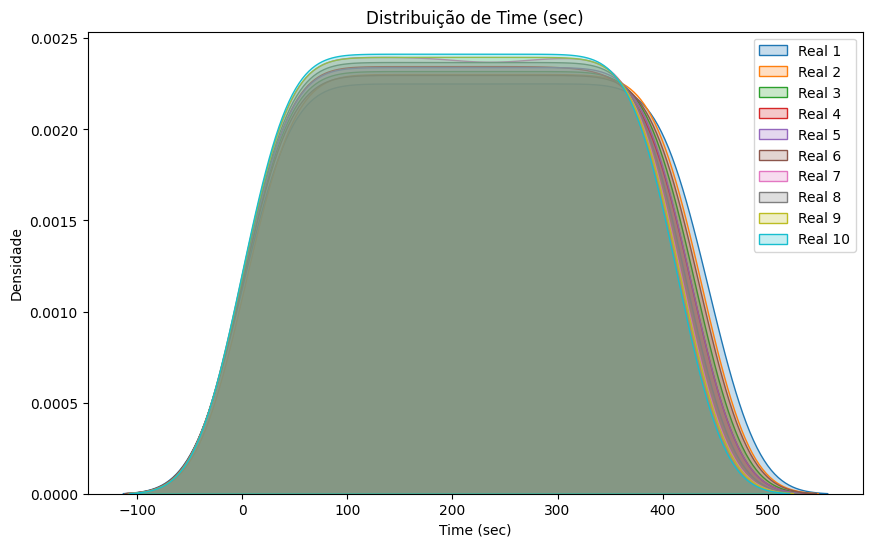

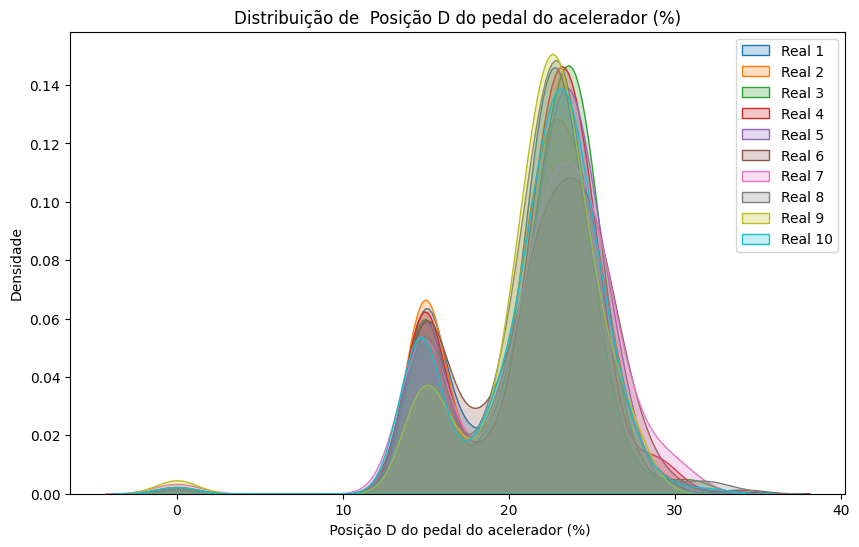

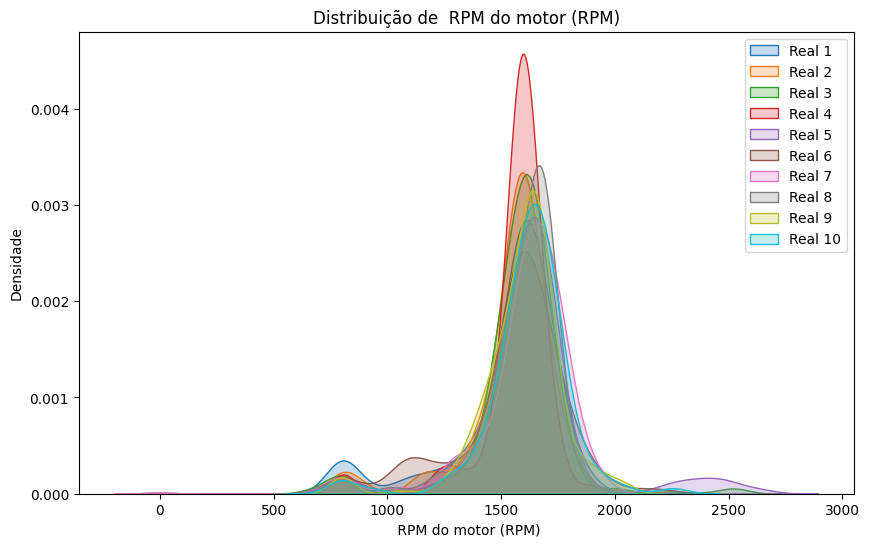

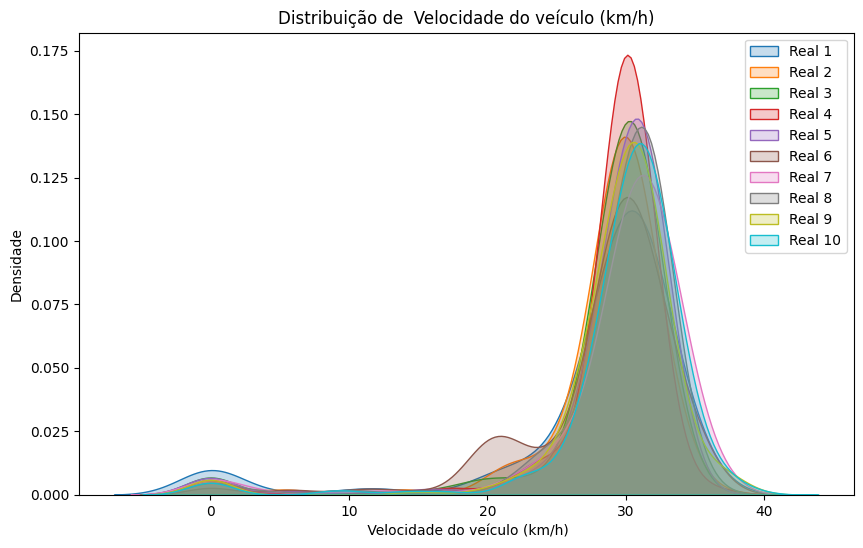

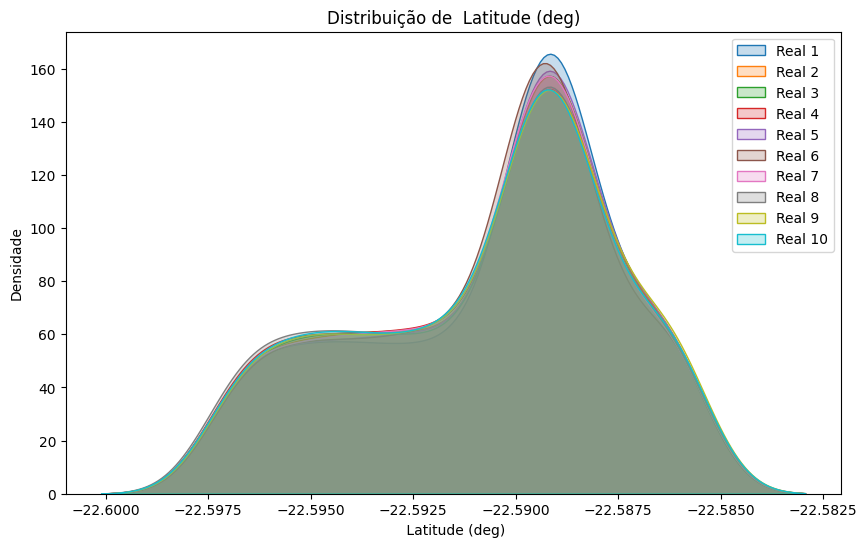

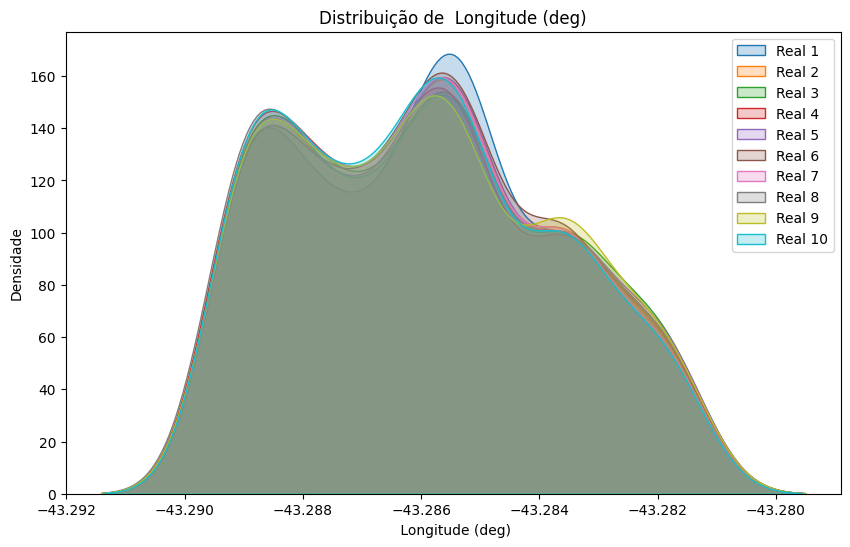

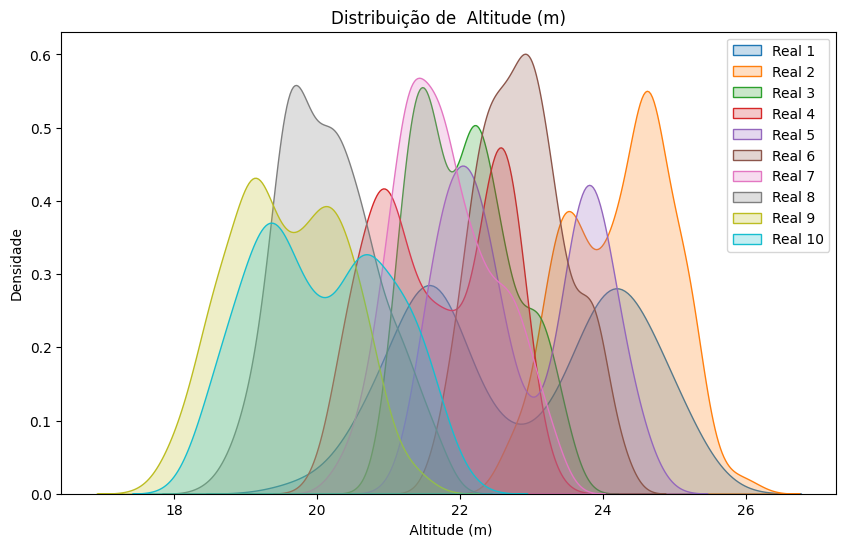

In [93]:
from os import listdir
import ast

reais = []

for file in listdir('circuito4'):
    reais.append(pd.read_csv(f'./circuito4/{file}', sep=','))

colluns = ['Time (sec)', ' Posição D do pedal do acelerador (%)', ' RPM do motor (RPM)', ' Velocidade do veículo (km/h)', ' Latitude (deg)', ' Longitude (deg)', ' Altitude (m)']

for collun in colluns:
    plt.figure(figsize=(10, 6))
    for i, real in enumerate(reais):
        sns.kdeplot(real[collun], label=f'Real {i+1}', fill=True)
    plt.title(f'Distribuição de {collun}')
    plt.xlabel(collun)
    plt.ylabel('Densidade')
    plt.legend()
    plt.show()

#### 1.3 Comparando o minimapa dos trajetos entre real e simulado

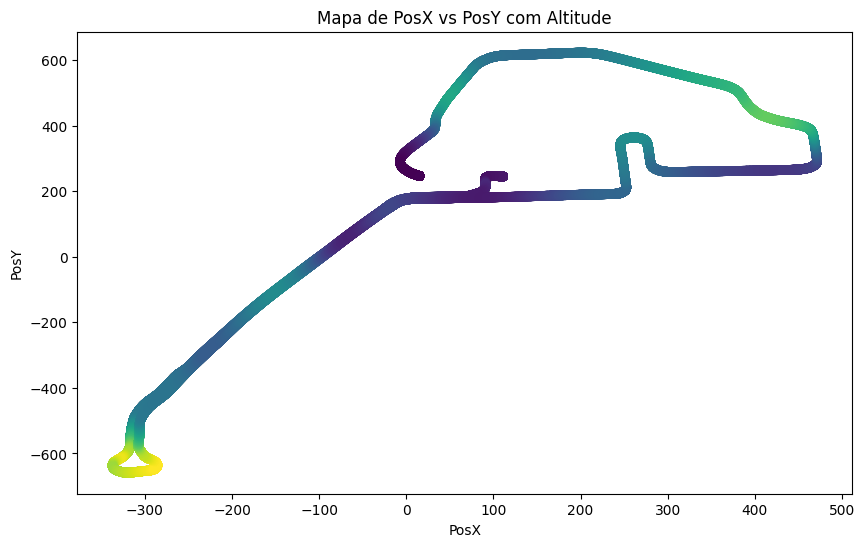

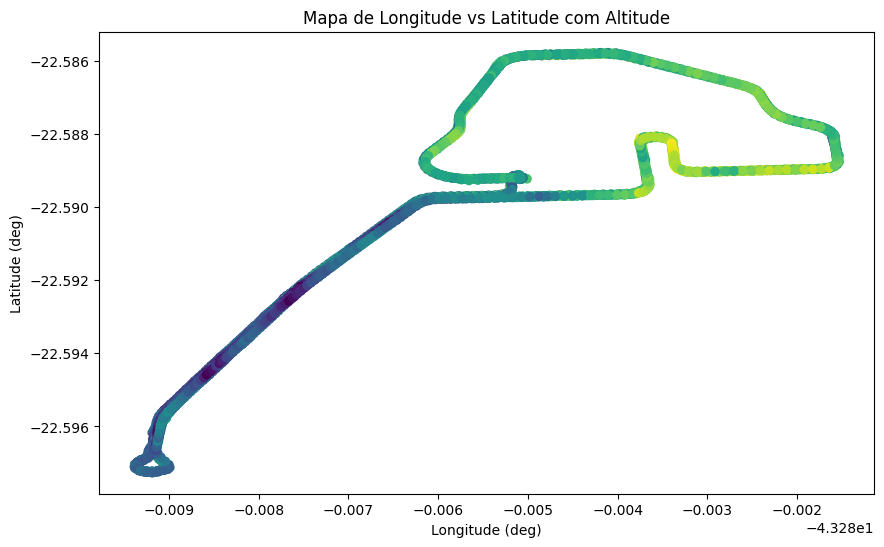

In [94]:
# Criando um mapa com posX, posY e posZ do beamng
plt.figure(figsize=(10, 6))
for simulado in simulados:
    plt.scatter(simulado['posX'], simulado['posY'], c=simulado['posZ'], cmap='viridis')
    plt.title('Mapa de PosX vs PosY com Altitude')
    plt.xlabel('PosX')
    plt.ylabel('PosY')
plt.show()

# Criando um mapa com Latitude, Longitude e Altitude dos dados reais
plt.figure(figsize=(10, 6))
for real in reais:
    plt.scatter(real[' Longitude (deg)'], real[' Latitude (deg)'], c=real[' Altitude (m)'], cmap='viridis')
    plt.title('Mapa de Longitude vs Latitude com Altitude')
    plt.xlabel('Longitude (deg)')
    plt.ylabel('Latitude (deg)')
plt.show()

### 2. Análises Estatísticas

In [95]:
# Fazendo a associação entre as colunas dos dados simulados e reais
colunas_simuladas = ['time', 'step', 'angle', 'posX', 'posY', 'posZ', 'fuel', 'brake_input', 'throttle', 'vel']
colunas_reais = ['Time (sec)', ' Posição D do pedal do acelerador (%)', ' RPM do motor (RPM)', ' Velocidade do veículo (km/h)', ' Latitude (deg)', ' Longitude (deg)', ' Altitude (m)']

colunas = {'time': 'Time (sec)', 'throttle': ' Posição D do pedal do acelerador (%)', 'vel': ' Velocidade do veículo (km/h)', 'posY': ' Latitude (deg)', 'posX': ' Longitude (deg)', 'posZ': ' Altitude (m)'}

In [96]:
# Renomeando as colunas dos dados simulados para facilitar a comparação
for simulado in simulados:
    simulado.rename(columns=colunas, inplace=True)

colunas = colunas.values()  # Pegando apenas os nomes das colunas reais para comparação

Antes de operar as análises estatísticas, deve-se realizar a normalização dos dados de ambos os datasets, de forma a desprezar as unidades de medida

In [97]:
df_all = pd.concat(
    [df[colunas] for df in reais + simulados],
    ignore_index=True
)

mean_vals = df_all.mean()
std_vals  = df_all.std()

def normalizar(df):
    return (df[colunas] - mean_vals) / std_vals

dfs_real_norm = [normalizar(df) for df in reais]
dfs_sim_norm  = [normalizar(df) for df in simulados]

#### 2.1 Comparação entre médias

In [98]:
from scipy.stats import ttest_ind

simulado = simulados[0]

for coluna in colunas:

    print(f'Comparando a coluna {coluna} entre os dados simulados e reais:\n')

    for i, real in enumerate(reais):
        stat, p = ttest_ind(simulado[coluna], real[coluna], equal_var=False)
        if p > 0.05:
            print(f'    Dataset {i+1} \033[92mPassou: p-value = {p:.4f}\n\033[0m')
        else:
            print(f'    Dataset {i+1} \033[91mFalhou: p-value = {p:.4f}\n\033[0m')
        

Comparando a coluna Time (sec) entre os dados simulados e reais:

    Dataset 1 Falhou: p-value = 0.0000

    Dataset 2 Falhou: p-value = 0.0000

    Dataset 3 Falhou: p-value = 0.0000

    Dataset 4 Falhou: p-value = 0.0000

    Dataset 5 Falhou: p-value = 0.0000

    Dataset 6 Falhou: p-value = 0.0000

    Dataset 7 Falhou: p-value = 0.0000

    Dataset 8 Falhou: p-value = 0.0000

    Dataset 9 Falhou: p-value = 0.0000

    Dataset 10 Falhou: p-value = 0.0000

Comparando a coluna  Posição D do pedal do acelerador (%) entre os dados simulados e reais:

    Dataset 1 Falhou: p-value = 0.0000

    Dataset 2 Falhou: p-value = 0.0000

    Dataset 3 Falhou: p-value = 0.0000

    Dataset 4 Falhou: p-value = 0.0000

    Dataset 5 Falhou: p-value = 0.0000

    Dataset 6 Falhou: p-value = 0.0000

    Dataset 7 Falhou: p-value = 0.0000

    Dataset 8 Falhou: p-value = 0.0000

    Dataset 9 Falhou: p-value = 0.0000

    Dataset 10 Falhou: p-value = 0.0000

Comparando a coluna  Velocidade do veíc

#### 2.2 Teste TOST para verificar semelhança

In [106]:
from statsmodels.stats.weightstats import ttost_ind

simulado = simulados[0]

for coluna in colunas:

    print(f'Comparando a coluna {coluna} entre os dados simulados e reais:\n')

    for i, real in enumerate(reais):
        p, g1, g2 = ttost_ind(simulado[coluna], real[coluna], low=-0.5, upp=0.5, usevar='unequal')
        if p < 0.05:
            print(f'    Dataset {i+1} \033[92mPassou: p-value = {p:.4f}\n\033[0m')
        else:
            print(f'    Dataset {i+1} \033[91mFalhou: p-value = {p:.4f}\n\033[0m')

Comparando a coluna Time (sec) entre os dados simulados e reais:

    Dataset 1 Falhou: p-value = 1.0000

    Dataset 2 Falhou: p-value = 1.0000

    Dataset 3 Falhou: p-value = 1.0000

    Dataset 4 Falhou: p-value = 1.0000

    Dataset 5 Falhou: p-value = 1.0000

    Dataset 6 Falhou: p-value = 1.0000

    Dataset 7 Falhou: p-value = 1.0000

    Dataset 8 Falhou: p-value = 1.0000

    Dataset 9 Falhou: p-value = 1.0000

    Dataset 10 Falhou: p-value = 1.0000

Comparando a coluna  Posição D do pedal do acelerador (%) entre os dados simulados e reais:

    Dataset 1 Falhou: p-value = 1.0000

    Dataset 2 Falhou: p-value = 1.0000

    Dataset 3 Falhou: p-value = 1.0000

    Dataset 4 Falhou: p-value = 1.0000

    Dataset 5 Falhou: p-value = 1.0000

    Dataset 6 Falhou: p-value = 1.0000

    Dataset 7 Falhou: p-value = 1.0000

    Dataset 8 Falhou: p-value = 1.0000

    Dataset 9 Falhou: p-value = 1.0000

    Dataset 10 Falhou: p-value = 1.0000

Comparando a coluna  Velocidade do veíc